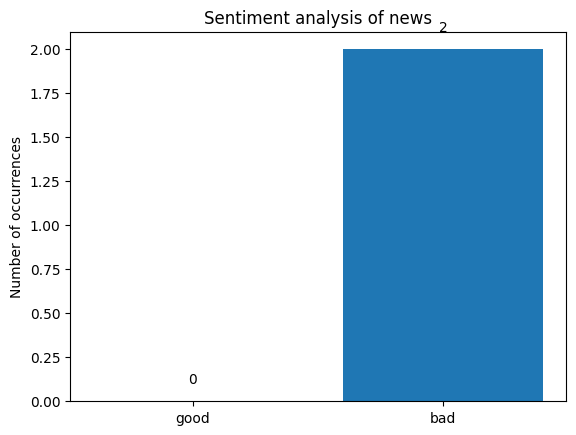


This is the news of 23/04/2026

 * Presidente da Alerj pede ao STF para assumir imediatamente governo do RJ

 * PF apura aplicação de R$ 13 milhões de previdência de cidade no Master

 * EUA reclassificam maconha medicinal como droga menos perigosa

 * Lula diz que vai levar jabuticaba para Trump para 'acalmá-lo'

 * Quais são os indícios que ligaram namorado à morte de miss no Rio

 * Sonecas longas e frequentes podem aumentar risco de mortalidade

 * Brasileira processa empresa de MrBeast por assédio sexual e moral

 * Acionistas da Warner Bros aprovam a aquisição pela Paramount

 * 1 preso morre a cada 19 h nas cadeias de SP —  a maioria por doenças tratáveis



In [39]:
import pandas as pd
import requests as rq
from datetime import datetime as dt
from bs4 import BeautifulSoup as bs
import matplotlib.pyplot as plt


# Function to collect news titles from G1
def get_funds_news():
  # URL of the target website (G1 news portal)
  url = 'https://g1.globo.com'

  # Headers simulate a real browser request (avoid blocking)
  headers = { 'User-Agent': 'Mozilla/5.0' }

  try:
    response = rq.get(url, headers=headers)

    # Raises an error if the request failed (status code != 200)
    response.raise_for_status()

    # Parse HTML content into a navigable structure
    theNews = bs(response.text, 'html.parser')

    # Find all <a> tags with the class 'feed-post-link' (news titles)
    links = theNews.find_all('a', class_='feed-post-link')

    titles = []

    # Extract and clean text from each link
    for link in links:
      title = link.text.strip()
      titles.append(title)

    return titles

  except Exception as e:
      print(f'Erro: {e}')

# ----------------------------------------------------

def countWords(titles):
    # Keywords representing positive context
    goodKeyWords = ['aumento', 'cresceu', 'aumentou', 'sobe', 'avança', 'salvou', 'salva', 'cura', 'resgata']

    # Keywords representing negative context
    badKeyWords = ['desce', 'diminuiu', 'queda', 'retrocede', 'morte', 'assassino', 'assassinou', 'mata', 'assédio']

    # Dictionary to store total occurrences by category
    counts = {
        'good': 0,
        'bad': 0
    }

    # Iterate through each title
    for title in titles:
        title_lower = title.lower()

        # Count occurrences of "positive" words
        for word in goodKeyWords:
            if word in title_lower:
                counts['good'] += 1

        # Count occurrences of "negative" words
        for word in badKeyWords:
            if word in title_lower:
                counts['bad'] += 1

    return counts

# ----------------------------------------------------

# Function to print Title
def printNews(titles):
  actualDay = dt.today()
  actualDay = actualDay.strftime('%d/%m/%Y')
  print(f"\nThis is the news of {actualDay}\n")
  for title in titles:
    print(f" * {title}\n")

# ----------------------------------------------------

# Function to create chart
def printGraphics(points):
  # Labels = categories (good / bad)
  labels = list(points.keys())

  # Values = number of occurrences
  values = list(points.values())

  # Create a new figure (canvas for the plot)
  plt.figure()

  # Create a bar chart
  plt.bar(labels, values)

  plt.title('Sentiment analysis of news')
  plt.ylabel('Number of occurrences')

  # Add value labels on top of each bar
  for i, v in enumerate(values):
      # i = position of the bar, v = value
      # v + 0.1 moves the text slightly above the bar
      plt.text(i, v + 0.1, str(v), ha='center')

  # Display the chart
  plt.show()

# ----------------------------------------------------

titles = get_funds_news()
points = countWords(titles)
printGraphics(points)
printNews(titles)


